In [ ]:
# Drive mount
from google.colab import drive
drive.mount('/content/drive')

# Basic libs.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os
from sklearn.ensemble import RandomForestRegressor

pd.options.display.max_rows = None
pd.options.display.max_columns = None

Mounted at /content/drive


In [ ]:
# Import the data.
DATA_DIR = '/content/drive/MyDrive/Colab Notebooks/house prices'
SAVE_DIR = '/content/drive/MyDrive/Colab Notebooks/house prices/submission'
train_df = pd.read_csv(f'{DATA_DIR}/train.csv')
test_df = pd.read_csv(f'{DATA_DIR}/test.csv')
print(f'(rows, columns) in tarin = {train_df.shape}\n(rows, columns) in test = {test_df.shape}\n')
print('Data structure:\n', train_df.head(5))

(rows, columns) in tarin = (1460, 81)
(rows, columns) in test = (1459, 80)

Data structure:
    Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities LotConfig LandSlope Neighborhood Condition1  \
0         Lvl    AllPub    Inside       Gtl      CollgCr       Norm   
1         Lvl    AllPub       FR2       Gtl      Veenker      Feedr   
2         Lvl    AllPub    Inside       Gtl      CollgCr       Norm   
3         Lvl    AllPub    Corner       Gtl      Crawfor       Norm   
4         Lvl    AllPub       FR2       Gtl      NoRidge       Norm   

  Condition2 BldgType HouseStyle  O

In [ ]:
# This dataset has 81 columns.
# Check them all.
print('All kinds of the columns:\n', train_df.columns)

All kinds of the columns:
 Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
     

missing values in traing data:
 PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageQual        81
GarageFinish      81
GarageType        81
GarageYrBlt       81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtCond          37
BsmtQual          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64


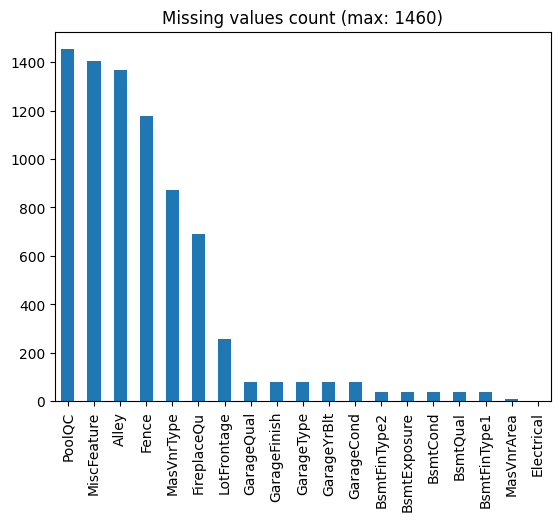

In [ ]:
# Check the missing values in train data.
missing_values_train = train_df.isna().sum().sort_values(ascending=False)
missing_values_train = missing_values_train[missing_values_train > 0]
print('missing values in traing data:\n', missing_values_train)

missing_values_train.plot(kind="bar")
plt.title("Missing values count (max: 1460)")
plt.show()

missing values in test data
 PoolQC          1456
MiscFeature     1408
Alley           1352
Fence           1169
MasVnrType       894
FireplaceQu      730
LotFrontage      227
GarageYrBlt       78
GarageCond        78
GarageFinish      78
GarageQual        78
GarageType        76
BsmtCond          45
BsmtQual          44
BsmtExposure      44
BsmtFinType1      42
BsmtFinType2      42
MasVnrArea        15
MSZoning           4
BsmtHalfBath       2
Utilities          2
Functional         2
BsmtFullBath       2
BsmtFinSF1         1
Exterior1st        1
TotalBsmtSF        1
BsmtUnfSF          1
BsmtFinSF2         1
SaleType           1
KitchenQual        1
GarageCars         1
GarageArea         1
Exterior2nd        1
dtype: int64


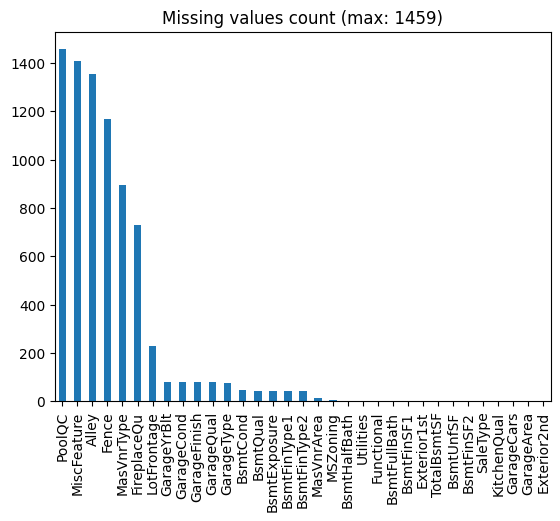

In [ ]:
# Check the missing values in test data.
missing_values_test = test_df.isna().sum().sort_values(ascending=False)
missing_values_test = missing_values_test[missing_values_test > 0]
print('missing values in test data\n', missing_values_test)

missing_values_test.plot(kind="bar")
plt.title("Missing values count (max: 1459)")
plt.show()

In [ ]:
# Check whether there are any columns exisit in either train data or test data.
train_na_cols = set(missing_values_train.index)
test_na_cols = set(missing_values_test.index)

only_in_train = train_na_cols - test_na_cols
only_in_test = test_na_cols - train_na_cols
print('Columns with missing values only in train_df:')
print(only_in_train)
print('\nColumns with missing values only in test_df:')
print(only_in_test)

Columns with missing values only in train_df:
{'Electrical'}

Columns with missing values only in test_df:
{'BsmtHalfBath', 'BsmtFinSF1', 'Functional', 'Utilities', 'BsmtFullBath', 'BsmtFinSF2', 'SaleType', 'BsmtUnfSF', 'GarageCars', 'KitchenQual', 'Exterior1st', 'TotalBsmtSF', 'GarageArea', 'MSZoning', 'Exterior2nd'}


In [ ]:
# Columns with missing values in both.
common_na_cols = train_na_cols & test_na_cols
print('Columns with missing values in both:')
print(common_na_cols)

Columns with missing values in both:
{'LotFrontage', 'GarageQual', 'BsmtExposure', 'MasVnrType', 'Fence', 'GarageFinish', 'BsmtCond', 'BsmtFinType1', 'BsmtQual', 'MiscFeature', 'GarageCond', 'GarageType', 'Alley', 'PoolQC', 'BsmtFinType2', 'MasVnrArea', 'FireplaceQu', 'GarageYrBlt'}


In [ ]:
# In "PoolQC", there are 1452 missing values.
# This is probably because almost all houses have no pool
# Check whether missing "PoolQC" means no pool.
print('examples of data:')
print(train_df[["PoolArea", "PoolQC"]].head(5))

print('\ndata of PoolArea in case of missing PoolQC in train:')
print(train_df.loc[train_df["PoolQC"].isnull(), "PoolArea"].describe())
print('\ndata of PoolArea in case of not missing PoolQC in train:')
print(train_df.loc[train_df["PoolQC"].notnull(), "PoolArea"].describe())

print('\ndata of PoolArea in case of missing PoolQC in test:')
print(test_df.loc[test_df["PoolQC"].isnull(), "PoolArea"].describe())
print('\ndata of PoolArea in case of not missing PoolQC in test:')
print(test_df.loc[test_df["PoolQC"].notnull(), "PoolArea"].describe())

examples of data:
   PoolArea PoolQC
0         0    NaN
1         0    NaN
2         0    NaN
3         0    NaN
4         0    NaN

data of PoolArea in case of missing PoolQC in train:
count    1453.0
mean        0.0
std         0.0
min         0.0
25%         0.0
50%         0.0
75%         0.0
max         0.0
Name: PoolArea, dtype: float64

data of PoolArea in case of not missing PoolQC in train:
count      7.000000
mean     575.428571
std       89.840335
min      480.000000
25%      515.500000
50%      555.000000
75%      612.000000
max      738.000000
Name: PoolArea, dtype: float64

data of PoolArea in case of missing PoolQC in test:
count    1456.000000
mean        0.942995
std        21.070757
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max       561.000000
Name: PoolArea, dtype: float64

data of PoolArea in case of not missing PoolQC in test:
count      3.000000
mean     390.666667
std      356.972455
min      144.000000
25%      186.0000

In [ ]:
# It turns out, in test data, there are some houses that
# "PoolQC" contains missing values although a pool exists.
has_pool_but_miss = test_df[(test_df['PoolQC'].isnull()) & (test_df['PoolArea']>0)]
print(has_pool_but_miss[['Id', 'PoolQC', 'PoolArea', 'OverallQual']])

        Id PoolQC  PoolArea  OverallQual
960   2421    NaN       368            4
1043  2504    NaN       444            6
1139  2600    NaN       561            3


In [ ]:
# Impute these 3 missing values with mode.
poolqc_mode = train_df['PoolQC'].mode()[0]
print('mode of "PoolQC":')
print(poolqc_mode)
test_df.loc[has_pool_but_miss.index, 'PoolQC'] = poolqc_mode
print('\ndata of PoolArea in case of missing PoolQC in test after imputating 3 missing values:')
print(test_df.loc[test_df["PoolQC"].isnull(), "PoolArea"].describe())

mode of "PoolQC":
Gd

data of PoolArea in case of missing PoolQC in test after imputating 3 missing values:
count    1453.0
mean        0.0
std         0.0
min         0.0
25%         0.0
50%         0.0
75%         0.0
max         0.0
Name: PoolArea, dtype: float64


In [ ]:
# Impute other missing velues in "PoolQC" with None.
train_df['PoolQC'] = train_df['PoolQC'].fillna('None')
print('missing values in "PoolQC" in train after imputing:')
print(train_df['PoolQC'].isna().sum())

test_df['PoolQC'] = test_df['PoolQC'].fillna('None')
print('\nmissing values in "PoolQC" in test after imputing:')
print(test_df['PoolQC'].isna().sum())

missing values in "PoolQC" in train after imputing:
0

missing values in "PoolQC" in test after imputing:
0


In [ ]:
# Several missing values are also seen in garage-related colums.
# The reason is maybe the same as pool, so check it.
garage_cols = [col for col in train_df.columns if 'Garage' in col]
print('missing values in garage-related colunms in train:')
print(train_df[garage_cols].isna().sum().sort_values(ascending=False))
print('\nmissing dat in train:')
print(train_df[train_df['GarageType'].isna()][garage_cols].head(5))

print('\nmissing values in garage-related columns in test:')
print(test_df[garage_cols].isna().sum().sort_values(ascending=False))
print('\nexceptional missing data in test:')
ex_gr_miss_test = test_df[(test_df['GarageQual'].isna()) & (test_df['GarageType'].notna())]
print(ex_gr_miss_test[garage_cols])

missing values in garage-related colunms in train:
GarageType      81
GarageYrBlt     81
GarageFinish    81
GarageCond      81
GarageQual      81
GarageArea       0
GarageCars       0
dtype: int64

missing dat in train:
   GarageType  GarageYrBlt GarageFinish  GarageCars  GarageArea GarageQual  \
39        NaN          NaN          NaN           0           0        NaN   
48        NaN          NaN          NaN           0           0        NaN   
78        NaN          NaN          NaN           0           0        NaN   
88        NaN          NaN          NaN           0           0        NaN   
89        NaN          NaN          NaN           0           0        NaN   

   GarageCond  
39        NaN  
48        NaN  
78        NaN  
88        NaN  
89        NaN  

missing values in garage-related columns in test:
GarageYrBlt     78
GarageFinish    78
GarageCond      78
GarageQual      78
GarageType      76
GarageArea       1
GarageCars       1
dtype: int64

exceptional missi

In [ ]:
# In test data, there are two exceptinal data.
# First, index 666 is filled in "GarageType", "GarageCar" and "GarageArea"
# but NaN in other 4 clumns.
# Impute missing values in "GarageYrBlt" with the same value as "YearBuilt",
# and the other missing values in other 3 clumns with mode.
test_df.loc[666, 'GarageYrBlt'] = test_df.loc[666, 'YearBuilt']
for col in ['GarageFinish', 'GarageQual', 'GarageCond']:
  mode = train_df[col].mode()[0]
  test_df.loc[666, col] = mode
  print(f'mode of {col}:', mode)

# Second, index 1116 is fillied in only "GarageType"
# but NaN in all of the other garage-related columns.
# Impute missing values in this house treating it as if it has no garage.
test_df.loc[1116, 'GarageType'] = 'None'

mode of GarageFinish: Unf
mode of GarageQual: TA
mode of GarageCond: TA


In [ ]:
# Impute missing values in categolical columns garage-related ones with None.
none_garage_cols = ['GarageType', 'GarageFinish', 'GarageQual', 'GarageCond']
train_df[none_garage_cols] = train_df[none_garage_cols].fillna('None')
print('missing values in garage-related categolical colunms after imputing')
print(train_df[none_garage_cols].isna().sum())

test_df[none_garage_cols] = test_df[none_garage_cols].fillna('None')
print('\nmissing values in garage-related categolical colunms after imputing')
print(test_df[none_garage_cols].isna().sum())

missing values in garage-related categolical colunms after imputing
GarageType      0
GarageFinish    0
GarageQual      0
GarageCond      0
dtype: int64

missing values in garage-related categolical colunms after imputing
GarageType      0
GarageFinish    0
GarageQual      0
GarageCond      0
dtype: int64


In [ ]:
# Impute missing values in "GarageYrBlt" with 0.
train_df['GarageYrBlt'] = train_df['GarageYrBlt'].fillna(0)
print('missing values in "GarageYrBlt" after imputing:')
print(train_df['GarageYrBlt'].isna().sum())

zero_garage_cols = ['GarageYrBlt', 'GarageCars', 'GarageArea']
test_df[zero_garage_cols] = test_df[zero_garage_cols].fillna(0)
print('\nmissing values in garage-related numerical colunms after imputing:')
print(test_df[zero_garage_cols].isna().sum())

missing values in "GarageYrBlt" after imputing:
0

missing values in garage-related numerical colunms after imputing:
GarageYrBlt    0
GarageCars     0
GarageArea     0
dtype: int64


In [ ]:
# Several missing values are also seen in basement-related colums as well.
# Check it in train data.
bsmt_cols = [col for col in train_df.columns if 'Bsmt' in col]
print('missing values in basement-related colunmsin train:')
print(train_df[bsmt_cols].isna().sum().sort_values(ascending=False))

print('\nmissing data:')
print(train_df[train_df['BsmtExposure'].isna()][bsmt_cols].head(5))

print('\nexamples of not missing data:')
print(train_df[train_df['BsmtExposure'].notna()][bsmt_cols].head(5))

missing values in basement-related colunmsin train:
BsmtExposure    38
BsmtFinType2    38
BsmtQual        37
BsmtCond        37
BsmtFinType1    37
BsmtFinSF1       0
BsmtFinSF2       0
BsmtUnfSF        0
TotalBsmtSF      0
BsmtFullBath     0
BsmtHalfBath     0
dtype: int64

missing data:
    BsmtQual BsmtCond BsmtExposure BsmtFinType1  BsmtFinSF1 BsmtFinType2  \
17       NaN      NaN          NaN          NaN           0          NaN   
39       NaN      NaN          NaN          NaN           0          NaN   
90       NaN      NaN          NaN          NaN           0          NaN   
102      NaN      NaN          NaN          NaN           0          NaN   
156      NaN      NaN          NaN          NaN           0          NaN   

     BsmtFinSF2  BsmtUnfSF  TotalBsmtSF  BsmtFullBath  BsmtHalfBath  
17            0          0            0             0             0  
39            0          0            0             0             0  
90            0          0            0     

In [ ]:
# Check the exceptations.
print('\ncheck the exceptions 1:')
print(train_df[(train_df['BsmtExposure'].isna()) & (train_df['BsmtQual'].notna())][bsmt_cols])

print('\ncheck the exceptions 2:')
print(train_df[(train_df['BsmtFinType2'].isna()) & (train_df['BsmtQual'].notna())][bsmt_cols])


check the exceptions 1:
    BsmtQual BsmtCond BsmtExposure BsmtFinType1  BsmtFinSF1 BsmtFinType2  \
948       Gd       TA          NaN          Unf           0          Unf   

     BsmtFinSF2  BsmtUnfSF  TotalBsmtSF  BsmtFullBath  BsmtHalfBath  
948           0        936          936             0             0  

check the exceptions 2:
    BsmtQual BsmtCond BsmtExposure BsmtFinType1  BsmtFinSF1 BsmtFinType2  \
332       Gd       TA           No          GLQ        1124          NaN   

     BsmtFinSF2  BsmtUnfSF  TotalBsmtSF  BsmtFullBath  BsmtHalfBath  
332         479       1603         3206             1             0  


In [ ]:
# 37 missing velues in the basement-related columns are caused because of
# non-existence of garage.
# Impute these 37 missing values with None.
miss_basement_cols = ['BsmtCond', 'BsmtQual', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2']
train_df.loc[train_df['BsmtQual'].isnull(), miss_basement_cols] = 'None'

# Impute the exceptation with mode ("BsmtExposure" and "BsmtFinType2").
exposure_mode = train_df['BsmtExposure'].mode()[0]
train_df.loc[948, 'BsmtExposure'] = exposure_mode
fintype2_mode = train_df['BsmtFinType2'].mode()[0]
train_df.loc[332, 'BsmtFinType2'] = fintype2_mode

print('missing values in garage-related colunms after imputing in train data:')
print(train_df[bsmt_cols].isna().sum().sort_values(ascending=False))

missing values in garage-related colunms after imputing in train data:
BsmtQual        0
BsmtCond        0
BsmtExposure    0
BsmtFinType1    0
BsmtFinSF1      0
BsmtFinType2    0
BsmtFinSF2      0
BsmtUnfSF       0
TotalBsmtSF     0
BsmtFullBath    0
BsmtHalfBath    0
dtype: int64


In [ ]:
# Check the missing values in basement-related columns in test data.
print('missing values in basement-related colunms in test:')
print(test_df[bsmt_cols].isna().sum().sort_values(ascending=False))
print('\nmissing data:')
print(test_df[test_df['BsmtExposure'].isna()][bsmt_cols].head(5))

missing values in basement-related colunms in test:
BsmtCond        45
BsmtQual        44
BsmtExposure    44
BsmtFinType1    42
BsmtFinType2    42
BsmtFullBath     2
BsmtHalfBath     2
BsmtFinSF2       1
BsmtFinSF1       1
TotalBsmtSF      1
BsmtUnfSF        1
dtype: int64

missing data:
    BsmtQual BsmtCond BsmtExposure BsmtFinType1  BsmtFinSF1 BsmtFinType2  \
27        Gd       TA          NaN          Unf         0.0          Unf   
125      NaN      NaN          NaN          NaN         0.0          NaN   
133      NaN      NaN          NaN          NaN         0.0          NaN   
269      NaN      NaN          NaN          NaN         0.0          NaN   
318      NaN      NaN          NaN          NaN         0.0          NaN   

     BsmtFinSF2  BsmtUnfSF  TotalBsmtSF  BsmtFullBath  BsmtHalfBath  
27          0.0     1595.0       1595.0           0.0           0.0  
125         0.0        0.0          0.0           0.0           0.0  
133         0.0        0.0          0.0     

In [ ]:
# Check the exceptions.
print('\ncheck the exceptions:')
print(test_df[test_df['BsmtFullBath'].isna()][bsmt_cols])

# It get clear that which data has missing value in SF-ralated columns,
# "BsmtFullBath" and "BsmtHalfBath".
none_basement_cols = ['BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2']
zero_basement_cols = ['BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath']

for ind in test_df[test_df['BsmtFullBath'].isna()].index:
  test_df.loc[ind, none_basement_cols] = 'None'
  test_df.loc[ind, zero_basement_cols] = 0

print('\nmissing values in basement-related colunms after partly imputing in test data:')
print(test_df[bsmt_cols].isna().sum().sort_values(ascending=False))


check the exceptions:
    BsmtQual BsmtCond BsmtExposure BsmtFinType1  BsmtFinSF1 BsmtFinType2  \
660      NaN      NaN          NaN          NaN         NaN          NaN   
728      NaN      NaN          NaN          NaN         0.0          NaN   

     BsmtFinSF2  BsmtUnfSF  TotalBsmtSF  BsmtFullBath  BsmtHalfBath  
660         NaN        NaN          NaN           NaN           NaN  
728         0.0        0.0          0.0           NaN           NaN  

missing values in basement-related colunms after partly imputing in test data:
BsmtCond        43
BsmtQual        42
BsmtExposure    42
BsmtFinType1    40
BsmtFinType2    40
BsmtFinSF1       0
BsmtFinSF2       0
BsmtUnfSF        0
TotalBsmtSF      0
BsmtFullBath     0
BsmtHalfBath     0
dtype: int64


In [ ]:
# Check the remaining exceptions.
basement_miss_data = test_df[test_df['BsmtCond'].isna()]
print('all missing values in "BsmtCond" in test data:')
print(basement_miss_data[miss_basement_cols])

print('\ncheck the exceptions missing in only "BsmtCond":')
ex_basement_BC = test_df[(test_df['BsmtCond'].isna()) & (test_df['BsmtQual'].notna())]
print(ex_basement_BC[miss_basement_cols])

print('\ncheck the exceptions about "BsmtQual":')
ex_basement_BQ = test_df[(test_df['BsmtCond'].notna()) & (test_df['BsmtQual'].isna())]
print(ex_basement_BQ[miss_basement_cols])

print('\ncheck the exceptions about "BsmtExposure":')
ex_basement_BE = test_df[(test_df['BsmtCond'].notna()) & (test_df['BsmtExposure'].isna())]
print(ex_basement_BE[miss_basement_cols])

all missing values in "BsmtCond" in test data:
     BsmtCond BsmtQual BsmtExposure BsmtFinType1 BsmtFinType2
125       NaN      NaN          NaN          NaN          NaN
133       NaN      NaN          NaN          NaN          NaN
269       NaN      NaN          NaN          NaN          NaN
318       NaN      NaN          NaN          NaN          NaN
354       NaN      NaN          NaN          NaN          NaN
387       NaN      NaN          NaN          NaN          NaN
388       NaN      NaN          NaN          NaN          NaN
396       NaN      NaN          NaN          NaN          NaN
397       NaN      NaN          NaN          NaN          NaN
398       NaN      NaN          NaN          NaN          NaN
400       NaN      NaN          NaN          NaN          NaN
455       NaN      NaN          NaN          NaN          NaN
580       NaN       Gd           Mn          GLQ          Rec
590       NaN      NaN          NaN          NaN          NaN
606       NaN      NaN 

In [ ]:
# Impute missing values one by one from the exceptions.
# 1. missing only in "BsmtCond"
# Use mode
mode_bsmtcond = train_df['BsmtCond'].mode()[0]
bsmtcond_miss_idx = [580, 725, 1064]
test_df.loc[bsmtcond_miss_idx, 'BsmtCond'] = mode_bsmtcond
print('mode of "BsmtCond":', mode_bsmtcond)

# 2. missing only in "BsmtQual"
# Use mode
mode_bsmtqual = train_df['BsmtQual'].mode()[0]
qual_miss_idx = [757, 758]
test_df.loc[qual_miss_idx, 'BsmtQual'] = mode_bsmtqual
print('mode of "BsmtQual":', mode_bsmtqual)

# 3. missing only in "BsmtExposure"
# Use mode
mode_bsmtexposure = train_df['BsmtExposure'].mode()[0]
exposure_miss_idx = [27, 888]
test_df.loc[ex_basement_BE.index, 'BsmtExposure'] = mode_bsmtexposure
print('mode of "BsmtExposure":', mode_bsmtexposure)

print('\nmissing values in basement-related colunms after partly imputing in test data:')
print(test_df[bsmt_cols].isna().sum().sort_values(ascending=False))

mode of "BsmtCond": TA
mode of "BsmtQual": TA
mode of "BsmtExposure": No

missing values in basement-related colunms after partly imputing in test data:
BsmtQual        40
BsmtCond        40
BsmtExposure    40
BsmtFinType1    40
BsmtFinType2    40
BsmtFinSF1       0
BsmtFinSF2       0
BsmtUnfSF        0
TotalBsmtSF      0
BsmtFullBath     0
BsmtHalfBath     0
dtype: int64


In [ ]:
# Finally, impute the remaining 40 missing values.
test_df.loc[test_df['BsmtQual'].isnull(), miss_basement_cols] = 'None'
print('missing values in basement-related colunms after fully imputing in test data:')
print(test_df[bsmt_cols].isna().sum().sort_values(ascending=False))

missing values in basement-related colunms after fully imputing in test data:
BsmtQual        0
BsmtCond        0
BsmtExposure    0
BsmtFinType1    0
BsmtFinSF1      0
BsmtFinType2    0
BsmtFinSF2      0
BsmtUnfSF       0
TotalBsmtSF     0
BsmtFullBath    0
BsmtHalfBath    0
dtype: int64


In [ ]:
# It seems that the other columns which have missing values sush as
# MiscFeature, Alley, Fence, MasVnrType, FireplaceQu, LotFrontage, MasVnrArea, Electrical,
# mean non-existence of kinds of facilities.
# Impute them with None.
none_cols = ['MiscFeature', 'Alley', 'Fence', 'MasVnrType', 'FireplaceQu']
train_df[none_cols] = train_df[none_cols].fillna('None')
print('missing values in non-existence columns after imputing in train data:')
print(train_df[none_cols].isna().sum())

test_df[none_cols] = test_df[none_cols].fillna('None')
print('\nmissing values in non-existence columns after imputing in test data:')
print(test_df[none_cols].isna().sum())

missing values in non-existence columns after imputing in train data:
MiscFeature    0
Alley          0
Fence          0
MasVnrType     0
FireplaceQu    0
dtype: int64

missing values in non-existence columns after imputing in test data:
MiscFeature    0
Alley          0
Fence          0
MasVnrType     0
FireplaceQu    0
dtype: int64


In [ ]:
# Impute missing values in "MasVnrArea" with 0.
train_df['MasVnrArea'] = train_df['MasVnrArea'].fillna(0)
print('missing values in "MasVnrArea" after imputing in train data:')
print(train_df['MasVnrArea'].isna().sum())

test_df['MasVnrArea'] = test_df['MasVnrArea'].fillna(0)
print('\nmissing values in "MasVnrArea" after imputing in test data:')
print(test_df['MasVnrArea'].isna().sum())

missing values in "MasVnrArea" after imputing in train data:
0

missing values in "MasVnrArea" after imputing in test data:
0


In [ ]:
# Impute a missing value in "Electrical" with mode in train data.
electrical_mode = train_df['Electrical'].mode()[0]
train_df['Electrical'] = train_df['Electrical'].fillna(electrical_mode)
print('missing values in "Electrical" after imputing:')
print(train_df['Electrical'].isna().sum())

missing values in "Electrical" after imputing:
0


In [ ]:
# About imputing missing velues in "LotFrontage".
# This column means the length of the property fronting the road.
# Every house must be frontage on a road, so the values seem pure omissions.

# The length is thought to be related with "Neighborhood",
# which means houses in suburban has a spacious lot
# while ones in urban do a narrow and elongated land.

# In addition, it may be related with "LotArea", the area of land,
# and "LotConfig", how it is positioned relative to the road.

neighborhood value counts
 Neighborhood
NAmes      225
CollgCr    150
OldTown    113
Edwards    100
Somerst     86
Gilbert     79
NridgHt     77
Sawyer      74
NWAmes      73
SawyerW     59
BrkSide     58
Crawfor     51
Mitchel     49
NoRidge     41
Timber      38
IDOTRR      37
ClearCr     28
SWISU       25
StoneBr     25
Blmngtn     17
MeadowV     17
BrDale      16
Veenker     11
NPkVill      9
Blueste      2
Name: count, dtype: int64


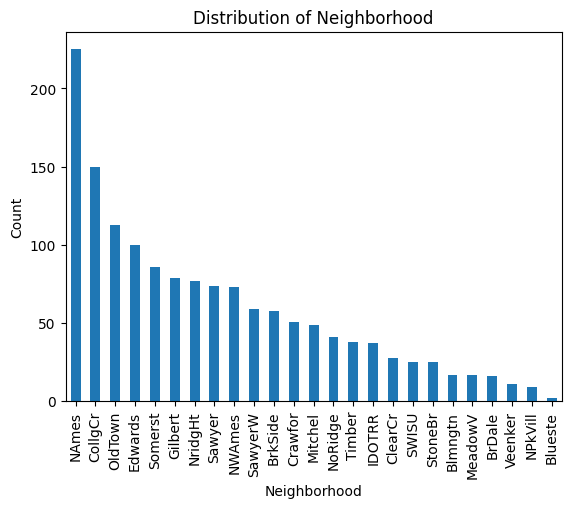

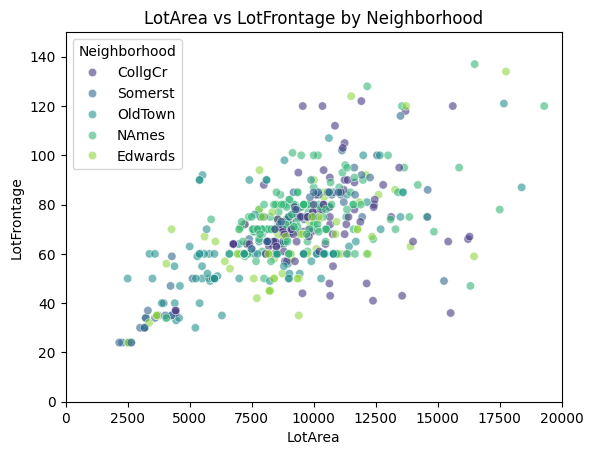

In [ ]:
# Check about "Neighborhood".
neighborhood = train_df['Neighborhood'].value_counts().sort_values(ascending=False)
print('neighborhood value counts\n', neighborhood)
neighborhood.plot(kind='bar')
plt.title('Distribution of Neighborhood')
plt.ylabel('Count')
plt.show()

# Check the relationship between "LotArea" and "LotFrontage" categolized by "Neighberhood",
# but it goes on only the categolies higher than 80.
major_neighborhoods = neighborhood[neighborhood >= 80].index.tolist()
df_major_neighborhoods = train_df[train_df['Neighborhood'].isin(major_neighborhoods)]

sns.scatterplot(data=df_major_neighborhoods, x='LotArea', y='LotFrontage', hue='Neighborhood', alpha=0.6, palette='viridis')
plt.xlim(0, 20000)
plt.ylim(0, 150)
plt.title('LotArea vs LotFrontage by Neighborhood')
plt.show()

In [ ]:
# There are a lot of categolies in "Neighborhood",
# and the relationship categolized by "Neighborhood" is vague,
# so don't use this as an explanatory variable in speculative model.

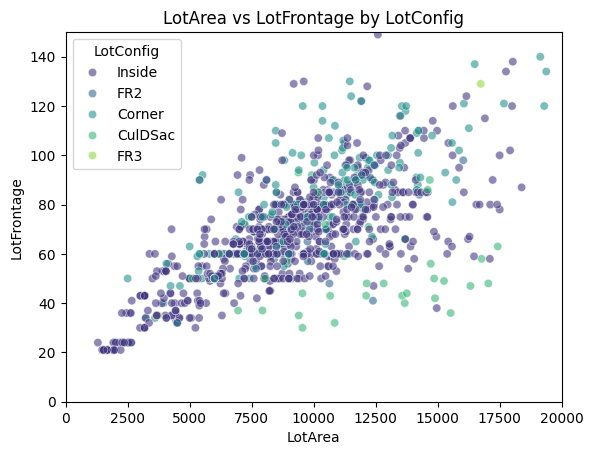

In [ ]:
# Check the relationship between "LotArea" and "LotFrontage" categolized by "LotConfig".
sns.scatterplot(data=train_df, x='LotArea', y='LotFrontage', hue='LotConfig', alpha=0.6, palette='viridis')
plt.xlim(0, 20000)
plt.ylim(0, 150)
plt.title('LotArea vs LotFrontage by LotConfig')
plt.show()

In [ ]:
# Impute the missing values in "LotFrontage" with the values speculated by
# a Random Forest model using "LotArea" and "LotConfig" as explanatory variables.

# 1. train data
impute_LF_clos = ['LotFrontage', 'LotArea', 'LotConfig']
df_LF = train_df[impute_LF_clos].copy()
df_LF_dummy = pd.get_dummies(df_LF, columns=['LotConfig'], prefix='Config')

train_LF_df = df_LF_dummy[df_LF_dummy['LotFrontage'].notnull()]
predict_LF_df = df_LF_dummy[df_LF_dummy['LotFrontage'].isnull()]

X_LF_train = train_LF_df.drop('LotFrontage', axis=1)
y_LF_train = train_LF_df['LotFrontage']

rf_LF_imputer = RandomForestRegressor(n_estimators=100, random_state=42)
rf_LF_imputer.fit(X_LF_train, y_LF_train)

X_LF_predict = predict_LF_df.drop('LotFrontage', axis=1)
predicted_LF_values = rf_LF_imputer.predict(X_LF_predict)

train_df.loc[train_df['LotFrontage'].isnull(), 'LotFrontage'] = predicted_LF_values

print('missing values in "LotFrontage" after imputing in train data:')
print(train_df['LotFrontage'].isna().sum())

# 2. test data
model_features = X_LF_train.columns

df_testLF = test_df[impute_LF_clos].copy()
df_testLF_dummy = pd.get_dummies(df_testLF, columns=['LotConfig'], prefix='Config')

X_testLF_predict = df_testLF_dummy[df_testLF_dummy['LotFrontage'].isnull()].reindex(columns=model_features, fill_value=0)
predicted_testLF_values = rf_LF_imputer.predict(X_testLF_predict)

test_df.loc[test_df['LotFrontage'].isnull(), 'LotFrontage'] = predicted_testLF_values

print('\nmissing values in "LotFrontage" after imputing in test data:')
print(test_df['LotFrontage'].isna().sum())

missing values in "LotFrontage" after imputing in train data:
0

missing values in "LotFrontage" after imputing in test data:
0


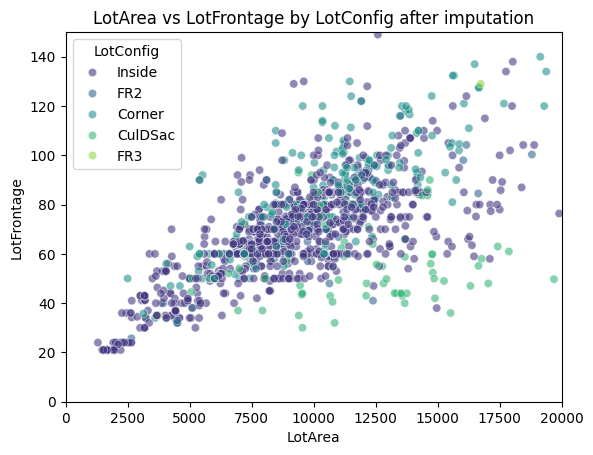

In [ ]:
# Check the relationship between "LotArea" and "LotFrontage"
# categolized by "LotConfig" after imputation.
sns.scatterplot(data=train_df, x='LotArea', y='LotFrontage', hue='LotConfig', alpha=0.6, palette='viridis')
plt.xlim(0, 20000)
plt.ylim(0, 150)
plt.title('LotArea vs LotFrontage by LotConfig after imputation')
plt.show()

In [ ]:
# Check whether all of missing values in tarin data are imputed properly.
print('missing values in traing data:\n', train_df.isnull().sum().sum())

missing values in traing data:
 0


In [ ]:
# Recheck how many missing values are remaining in test data.
missing_values_test = test_df.isna().sum().sort_values(ascending=False)
missing_values_test = missing_values_test[missing_values_test > 0]
print('missing values in test data\n', missing_values_test)

missing values in test data
 MSZoning       4
Utilities      2
Functional     2
Exterior1st    1
Exterior2nd    1
KitchenQual    1
SaleType       1
dtype: int64


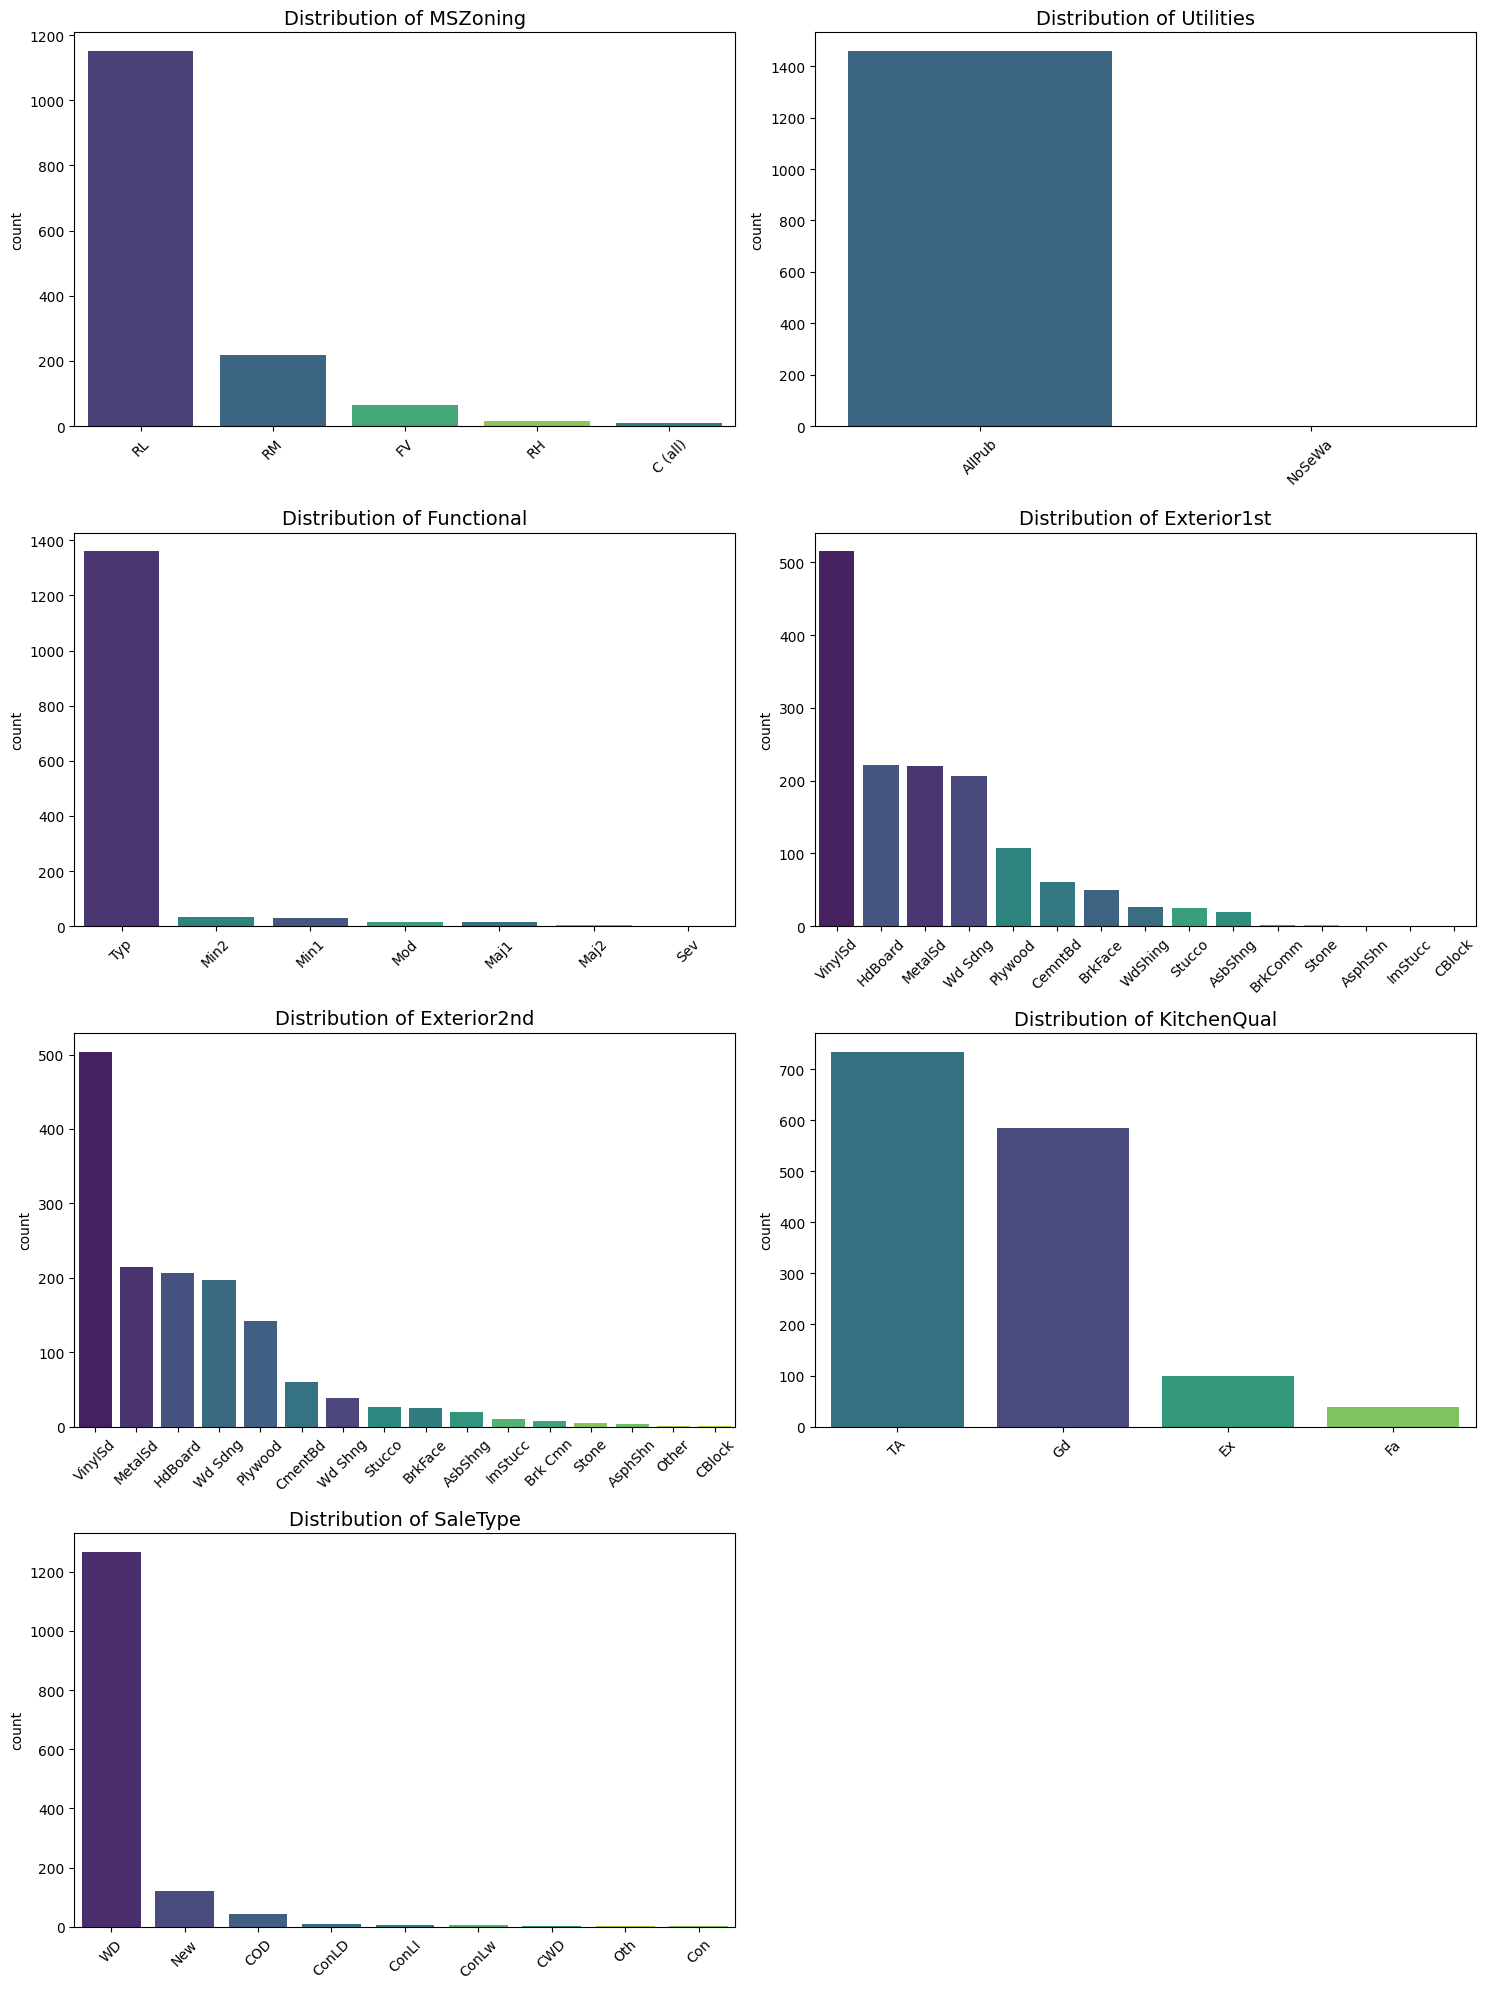

In [ ]:
# Check the distribution of data in the colums that still have missing valures in test data.
minor_na_cols = ['MSZoning', 'Utilities', 'Functional', 'Exterior1st',
                 'Exterior2nd', 'KitchenQual', 'SaleType']

fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(15, 20))
axes = axes.flatten()

for i, col in enumerate(minor_na_cols):
    sns.countplot(data=train_df, x=col, ax=axes[i], hue=col, palette='viridis',
                  order=train_df[col].value_counts().index, legend=False)
    axes[i].set_title(f'Distribution of {col}', fontsize=14)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45)

if len(minor_na_cols) < len(axes):
    axes[-1].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# Impute the remaining missing values in test data with mode.
for col in minor_na_cols:
  mode = train_df[col].mode()[0]
  test_df[col] = test_df[col].fillna(mode)

print('missing values in test data:', test_df.isna().sum().sum())

missing values in test data: 0


In [ ]:
# Start Feature Engineering.

Each correlation with "SalePrice":
OverallQual      0.790982
GrLivArea        0.708624
GarageCars       0.640409
GarageArea       0.623431
TotalBsmtSF      0.613581
1stFlrSF         0.605852
FullBath         0.560664
TotRmsAbvGrd     0.533723
YearBuilt        0.522897
YearRemodAdd     0.507101
MasVnrArea       0.472614
Fireplaces       0.466929
BsmtFinSF1       0.386420
LotFrontage      0.327627
WoodDeckSF       0.324413
2ndFlrSF         0.319334
OpenPorchSF      0.315856
HalfBath         0.284108
LotArea          0.263843
GarageYrBlt      0.261366
BsmtFullBath     0.227122
BsmtUnfSF        0.214479
BedroomAbvGr     0.168213
ScreenPorch      0.111447
PoolArea         0.092404
MoSold           0.046432
3SsnPorch        0.044584
BsmtFinSF2      -0.011378
BsmtHalfBath    -0.016844
MiscVal         -0.021190
LowQualFinSF    -0.025606
YrSold          -0.028923
OverallCond     -0.077856
MSSubClass      -0.084284
EnclosedPorch   -0.128578
KitchenAbvGr    -0.135907
Name: SalePrice, dtype: float

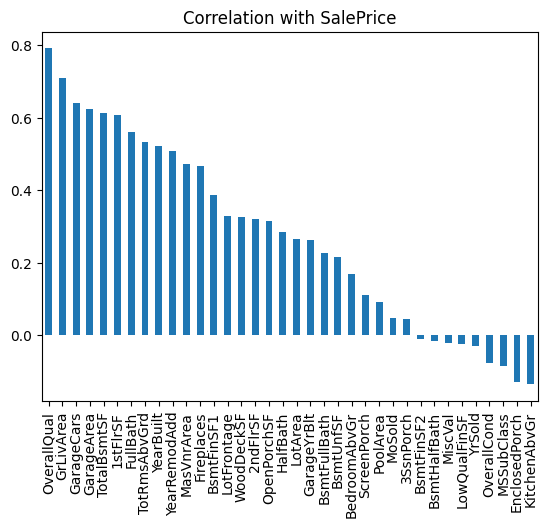

In [ ]:
# Begining with checking the correlation with "SalePrice".
print('Each correlation with "SalePrice":')
corr_with_price = train_df.corr(numeric_only=True)['SalePrice'].sort_values(ascending=False)
corr_with_price = corr_with_price.drop(['SalePrice', 'Id'])
print(corr_with_price)

corr_with_price.plot(kind='bar')
plt.title('Correlation with SalePrice')
plt.show()

missing values: 0


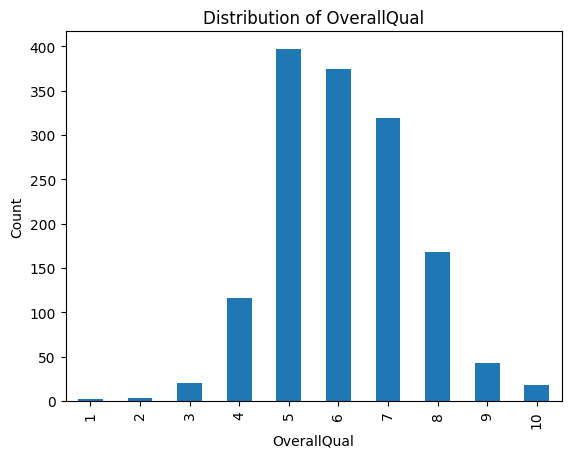

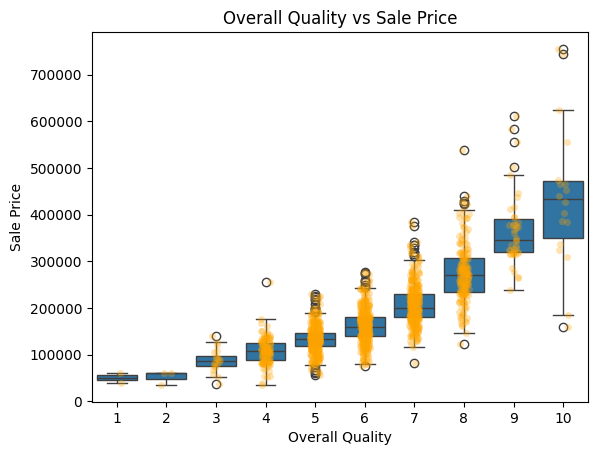

In [ ]:
# "OverallQual" is Overall Material and Finish Quality,
# which means the reputation of quality about kinds of materials of the house.

# Visualize relationship between OverallQual and SalePrice.
print('missing values:', train_df['OverallQual'].isna().sum())

overallqual = train_df['OverallQual'].value_counts().sort_index()
overallqual.plot(kind='bar')
plt.title('Distribution of OverallQual')
plt.ylabel('Count')
plt.show()

sns.boxplot(x='OverallQual', y='SalePrice', data=train_df)
sns.stripplot(x='OverallQual', y='SalePrice', data=train_df, color="orange", jitter=True, alpha=0.3)
plt.title('Overall Quality vs Sale Price')
plt.xlabel('Overall Quality')
plt.ylabel('Sale Price')
plt.show()

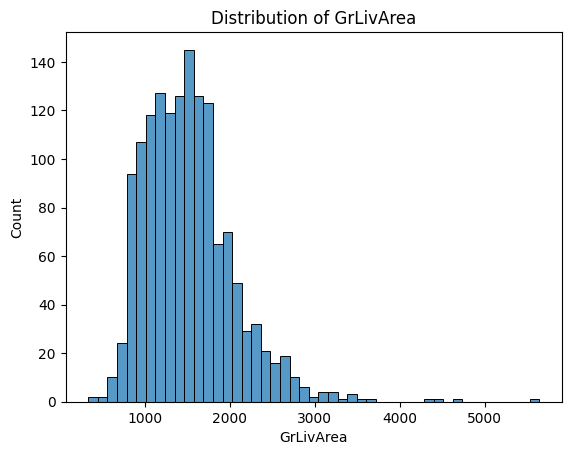

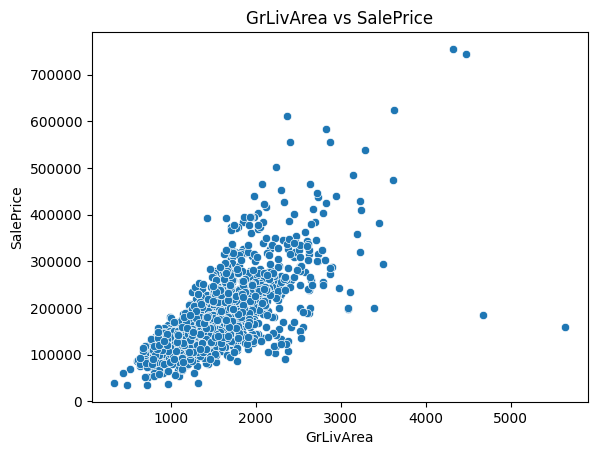

In [ ]:
# "GrLivArea" is Above Grade Living Area Square Feet,
# which means the area of above ground.
# This doesn't include the are of basements.

# Visualize relationship between GrLivArea and SalePrice
sns.histplot(train_df['GrLivArea'])
plt.title('Distribution of GrLivArea')
plt.show()

sns.scatterplot(x=train_df["GrLivArea"], y=train_df["SalePrice"])
plt.title("GrLivArea vs SalePrice")
plt.show()

candidates of outliners:
         Id  GrLivArea  SalePrice
523    524       4676     184750
1298  1299       5642     160000


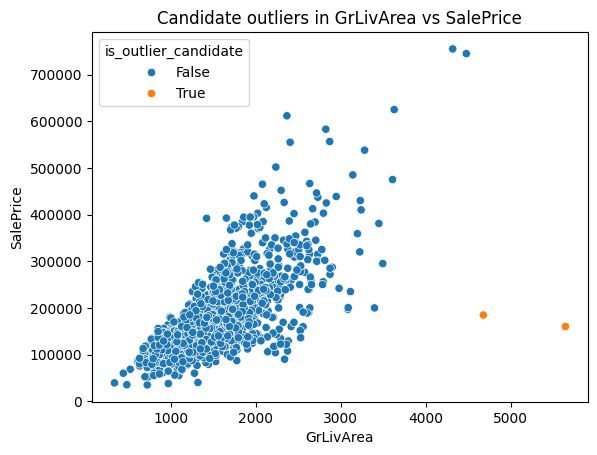

In [ ]:
# Inspect suspicious large-area houses with relatively low price.
# Mark them as candidates of outliners.
high_grlivarea_low_saleprice = train_df[(train_df['GrLivArea'] > 4000) & (train_df['SalePrice'] < 400000)]
print('candidates of outliners:\n', high_grlivarea_low_saleprice[['Id', 'GrLivArea', 'SalePrice']])

train_df_outliner_check = train_df.copy()
train_df_outliner_check["is_outlier_candidate"] = ((train_df["GrLivArea"] > 4000) & (train_df["SalePrice"] < 400000))
sns.scatterplot(data=train_df_outliner_check, x="GrLivArea", y="SalePrice", hue="is_outlier_candidate")
plt.title("Candidate outliers in GrLivArea vs SalePrice")
plt.show()

# Keep these index handy for removal.
outlier_candidates_index = high_grlivarea_low_saleprice.index

# Eventually, the final score is higer in the case of remaining these data.

In [ ]:
# Check categolical columns.
print('Categolical columns:')
print(train_df.select_dtypes('object').columns)

Categolical columns:
Index(['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature',
       'SaleType', 'SaleCondition'],
      dtype='object')


In [ ]:
# Categolize these colums for ordinal encoding.
# By converting categorical rankings into meaningful numerical scales (1-5),
# the model can understand the relative order of quality.

original_numeric_cols = train_df.select_dtypes(include=[np.number]).drop('SalePrice', axis=1).columns

# 1. Quality & Condition: Ex(5) > Gd(4) > TA(3) > Fa(2) > Po(1) > None(0)
qual_mapping = {"Ex": 5, "Gd": 4, "TA": 3, "Fa": 2, "Po": 1, "None": 0}
qual_cols = ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'HeatingQC',
             'KitchenQual', 'FireplaceQu', 'GarageQual', 'GarageCond', 'PoolQC']

for col in qual_cols:
    train_df[col] = train_df[col].map(qual_mapping)
    test_df[col] = test_df[col].map(qual_mapping)

print('check data after conveting:')
print(train_df[qual_cols].head())

check data after conveting:
   ExterQual  ExterCond  BsmtQual  BsmtCond  HeatingQC  KitchenQual  \
0          4          3         4         3          5            4   
1          3          3         4         3          5            3   
2          4          3         4         3          5            4   
3          3          3         3         4          4            4   
4          4          3         4         3          5            4   

   FireplaceQu  GarageQual  GarageCond  PoolQC  
0            0           3           3       0  
1            3           3           3       0  
2            3           3           3       0  
3            4           3           3       0  
4            3           3           3       0  


In [ ]:
# 2. Finished State of Basement: GLQ(6) > ALQ(5) > BLQ(4) > Rec(3) > LwQ(2) > Unf(1) > None(0)
finish_mapping = {"GLQ": 6, "ALQ": 5, "BLQ": 4, "Rec": 3, "LwQ": 2, "Unf": 1, "None": 0}
finish_cols = ['BsmtFinType1', 'BsmtFinType2']

for col in finish_cols:
    train_df[col] = train_df[col].map(finish_mapping)
    test_df[col] = test_df[col].map(finish_mapping)

print('check data after conveting:')
print(train_df[finish_cols].head())

check data after conveting:
   BsmtFinType1  BsmtFinType2
0             6             1
1             5             1
2             6             1
3             5             1
4             6             1


In [ ]:
# 3. Others:
#.   BsmtExposure: Gd(4) > Av(3) > Mn(2) > No(1) > None(0)
#.   GarageFinish: Fin(3) > RFn(2) > Unf(1) > None(0)
#.   Functional: Typ(7) > Min1(6) > Min2(5) > Mod(4) > Maj1(3) > Maj2(2) > Sev(1) > Sal(0)
#.   PavedDrive: Y(2) > P(1) > N(0)
#.   LandSlope: Gtl(Gentle: 2) > Mod(Moderate: 1) > Sev(Severe: 0)
exposure_mapping = {"Gd": 4, "Av": 3, "Mn": 2, "No": 1, "None": 0}
garage_finish_mapping = {"Fin": 3, "RFn": 2, "Unf": 1, "None": 0}
functional_mapping = {"Typ": 7, "Min1": 6, "Min2": 5, "Mod": 4,
                      "Maj1": 3, "Maj2": 2, "Sev": 1, "Sal": 0}
paved_mapping = {"Y": 2, "P": 1, "N": 0}
slope_mapping = {"Gtl": 2, "Mod": 1, "Sev": 0}

train_df['BsmtExposure'] = train_df['BsmtExposure'].map(exposure_mapping)
test_df['BsmtExposure'] = test_df['BsmtExposure'].map(exposure_mapping)

train_df['GarageFinish'] = train_df['GarageFinish'].map(garage_finish_mapping)
test_df['GarageFinish'] = test_df['GarageFinish'].map(garage_finish_mapping)

train_df['Functional'] = train_df['Functional'].map(functional_mapping)
test_df['Functional'] = test_df['Functional'].map(functional_mapping)

train_df['PavedDrive'] = train_df['PavedDrive'].map(paved_mapping)
test_df['PavedDrive'] = test_df['PavedDrive'].map(paved_mapping)

train_df['LandSlope'] = train_df['LandSlope'].map(slope_mapping)
test_df['LandSlope'] = test_df['LandSlope'].map(slope_mapping)

print('check data after conveting:')
print(train_df[['BsmtExposure', 'GarageFinish', 'Functional', 'PavedDrive', 'LandSlope']].head())

check data after conveting:
   BsmtExposure  GarageFinish  Functional  PavedDrive  LandSlope
0             1             2           7           2          2
1             4             2           7           2          2
2             2             2           7           2          2
3             1             1           7           2          2
4             3             2           7           2          2


In [ ]:
# Check if these ordinal variables are properly converted in correct order.
ordinal_cols = [
    'ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'HeatingQC',
    'KitchenQual', 'FireplaceQu', 'GarageQual', 'GarageCond', 'PoolQC',
    'BsmtFinType1', 'BsmtFinType2', 'BsmtExposure', 'GarageFinish',
    'Functional', 'PavedDrive', 'LandSlope'
]

print("average SalePrice (log) per category value:")
for col in ordinal_cols:
    group_means = train_df.groupby(col)['SalePrice'].mean().sort_index()
    print(f"\nVariable: {col}")
    print(group_means)

average SalePrice (log) per category value:

Variable: ExterQual
ExterQual
2     87985.214286
3    144341.313466
4    231633.510246
5    367360.961538
Name: SalePrice, dtype: float64

Variable: ExterCond
ExterCond
1     76500.000000
2    102595.142857
3    184034.896256
4    168897.568493
5    201333.333333
Name: SalePrice, dtype: float64

Variable: BsmtQual
BsmtQual
0    105652.891892
2    115692.028571
3    140759.818182
4    202688.478964
5    327041.041322
Name: SalePrice, dtype: float64

Variable: BsmtCond
BsmtCond
0    105652.891892
1     64000.000000
2    121809.533333
3    183632.620900
4    213599.907692
Name: SalePrice, dtype: float64

Variable: HeatingQC
HeatingQC
1     87000.000000
2    123919.489796
3    142362.876168
4    156858.871369
5    214914.429150
Name: SalePrice, dtype: float64

Variable: KitchenQual
KitchenQual
2    105565.205128
3    139962.511565
4    212116.023891
5    328554.670000
Name: SalePrice, dtype: float64

Variable: FireplaceQu
FireplaceQu
0    141331

In [ ]:
# Create 3 new features about areas.
# 1. "TotalSF": total floor area of the eintire house ("GrLivArea" + "TotalBamtSF")
# 2. "TotalPorchSF": total area of outdoor recreational spaces
# 3. "Has2ndFlr": whether the house has a 2nd floor or not
for df in [train_df, test_df]:
    df['TotalSF'] = df['GrLivArea'] + df['TotalBsmtSF']

    df['TotalPorchSF'] = (df['OpenPorchSF'] + df['EnclosedPorch'] +
                          df['3SsnPorch'] + df['ScreenPorch'] + df['WoodDeckSF'])

    df['Has2ndFlr'] = (df['2ndFlrSF'] > 0).astype(int)

print('check the new features:')
print(train_df[['TotalSF', 'TotalPorchSF', 'Has2ndFlr']].head())

check the new features:
   TotalSF  TotalPorchSF  Has2ndFlr
0     2566            61          1
1     2524           298          0
2     2706            42          1
3     2473           307          1
4     3343           276          1


In [ ]:
# Create 2 new features about areas x quality.
# 4. "TotalSF_x_Qual": total area multiplied by overall quality
# 5. "BsmtSF_x_Qual": total basement area multiplied by its quality
for df in [train_df, test_df]:
    df['TotalSF_x_Qual'] = df['TotalSF'] * df['OverallQual']

    df['Bsmt_x_Qual'] = df['TotalBsmtSF'] * df['BsmtQual']

print('check the new features:')
print(train_df[['TotalSF_x_Qual', 'Bsmt_x_Qual']].head())

check the new features:
   TotalSF_x_Qual  Bsmt_x_Qual
0           17962         3424
1           15144         5048
2           18942         3680
3           17311         2268
4           26744         4580


In [ ]:
# Create 2 new features about ages.
# 6. "HouseAge": substract the year of constraction from the year of sale
# 7. "YearSinceRemod": sbstract the year of reconstruction from the year of sale
for df in [train_df, test_df]:
    df['HouseAge'] = df['YrSold'] - df['YearBuilt']

    df['YearsSinceRemod'] = df['YrSold'] - df['YearRemodAdd']

# Since the age of construction may become negative, clip it at zero.
train_df['HouseAge'] = train_df['HouseAge'].apply(lambda x: max(0, x))
test_df['HouseAge'] = test_df['HouseAge'].apply(lambda x: max(0, x))

print('check the new features:')
print(train_df[['HouseAge', 'YearsSinceRemod']].head())

check the new features:
   HouseAge  YearsSinceRemod
0         5                5
1        31               31
2         7                6
3        91               36
4         8                8


In [ ]:
# Create a new feature about bath.
# 8. "ToatalBath": the total number of bath
for df in [train_df, test_df]:
    df['TotalBath'] = (df['FullBath'] + (0.5 * df['HalfBath']) +
                       df['BsmtFullBath'] + (0.5 * df['BsmtHalfBath']))

print('check the new features:')
print(train_df[['TotalBath']].head())

check the new features:
   TotalBath
0        3.5
1        2.5
2        3.5
3        2.0
4        3.5


In [ ]:
# Check number of colums after created 8 new features; whether were created properly.
print('original number of colums:\n81')
print('number of colums after created 8 new features:')
print(len(train_df.columns))

original number of colums:
81
number of colums after created 8 new features:
89


In [ ]:
# Check skewness of other numeric features.
new_cols = ['TotalSF', 'TotalPorchSF', 'Has2ndFlr',
            'TotalSF_x_Qual', 'Bsmt_x_Qual',
            'HouseAge', 'YearsSinceRemod',
            'TotalBath']
numeric_cols = original_numeric_cols.tolist() + new_cols
skewed_feats = train_df[numeric_cols].apply(lambda x: x.skew()).sort_values(ascending=False)
high_skew = skewed_feats[abs(skewed_feats) > 0.75]
print(f"Skews in {high_skew.shape[0]} numerical features (>0.75):\n", high_skew)


Skews in 26 numerical features (>0.75):
 MiscVal           24.476794
PoolArea          14.828374
LotArea           12.207688
3SsnPorch         10.304342
LowQualFinSF       9.011341
KitchenAbvGr       4.488397
BsmtFinSF2         4.255261
ScreenPorch        4.122214
BsmtHalfBath       4.103403
EnclosedPorch      3.089872
MasVnrArea         2.677616
TotalSF_x_Qual     2.439608
OpenPorchSF        2.364342
Bsmt_x_Qual        2.322639
LotFrontage        2.029780
TotalSF            1.778029
BsmtFinSF1         1.685503
WoodDeckSF         1.541376
TotalBsmtSF        1.524255
MSSubClass         1.407657
1stFlrSF           1.376757
GrLivArea          1.366560
TotalPorchSF       1.102313
BsmtUnfSF          0.920268
2ndFlrSF           0.813030
GarageYrBlt       -3.869501
dtype: float64


In [ ]:
# To normalize highly skewed distributions and improve model stability,
# apply log1p transformation to numerical features with skewness > 0.75.
high_skew_cols = high_skew.index

for col in high_skew_cols:
    # Using np.log1p allows handling values of zero.
    train_df[col] = np.log1p(train_df[col])
    test_df[col] = np.log1p(test_df[col])

print(f'Successfully log-transformed {len(high_skew_cols)} features.')

Successfully log-transformed 26 features.


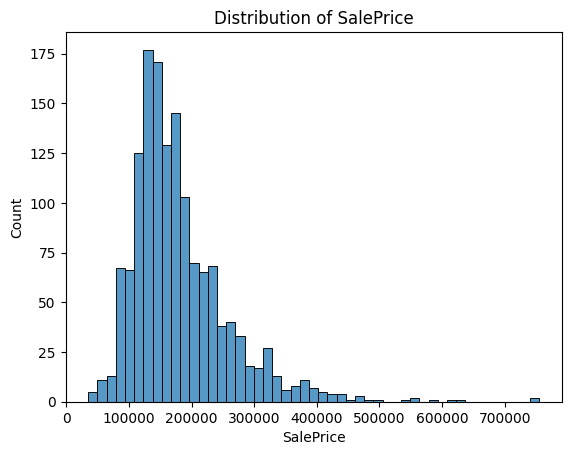


Skewness of SalePrice: 1.8828757597682129
Kurtosis of SalePrice: 6.536281860064529


In [ ]:
# Check the distribution of SalePrices.
sns.histplot(train_df['SalePrice'])
plt.title('Distribution of SalePrice')
plt.show()
print("\nSkewness of SalePrice:", train_df["SalePrice"].skew())
print("Kurtosis of SalePrice:", train_df["SalePrice"].kurt())

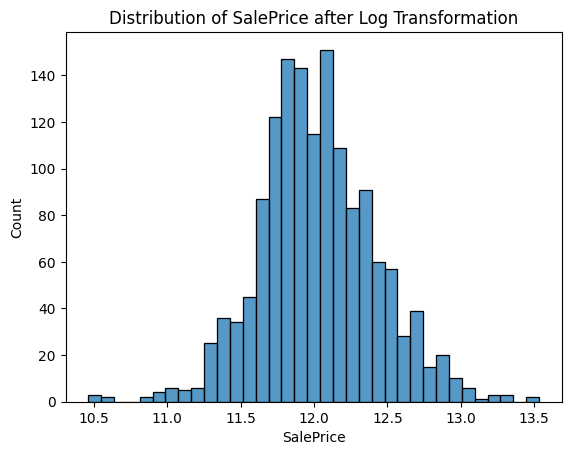


Skewness of SalePrice after transformation: 0.12134661989685333
Kurtosis of SalePrice after transformation: 0.809519155707878


In [ ]:
# Since "SalePrice" deviates significantly from a normal distribution,
# apply a log transfomation.
train_df['SalePrice'] = np.log1p(train_df['SalePrice'])
sns.histplot(train_df['SalePrice'])
plt.title('Distribution of SalePrice after Log Transformation')
plt.show()
print("\nSkewness of SalePrice after transformation:", train_df["SalePrice"].skew())
print("Kurtosis of SalePrice after transformation:", train_df["SalePrice"].kurt())

In [ ]:
# One-hot encoding for remaining categorical features (not ordinal ones).
end_of_train = train_df.shape[0]
all_data = pd.concat([train_df, test_df], axis=0).reset_index(drop=True)
all_data = pd.get_dummies(all_data, dtype=int)

train_df = all_data[:end_of_train]
test_df = all_data[end_of_train:]

In [ ]:
# Modeling Phase.
# Considering 3 models, LightGBM, Lasso Regression, Ridge Regression.
X_train = train_df.drop(['SalePrice'], axis=1)
y_train = train_df['SalePrice']

In [ ]:
# Use Lasso to handle high-dimensional data and
# perform automatic feature selection through L1 regularization.
from sklearn.linear_model import LassoCV
from sklearn.model_selection import cross_val_score

# Automatically select the appropriate alpha.
# cv = 5
lasso = LassoCV(alphas=[0.0001, 0.0003, 0.0006, 0.001, 0.003, 0.006, 0.01], max_iter=50000, cv=5)
lasso.fit(X_train, y_train)
print('alpha:', lasso.alpha_)

# Evaluate the model using RMSE.
rmse = np.sqrt(-cross_val_score(lasso, X_train, y_train, scoring="neg_mean_squared_error", cv=5))
print('Lasso Score (RMSE):')
print(f"mean: {rmse.mean():.4f}")
print(f"std: {rmse.std():.4f}")

alpha: 0.0006
Lasso Score (RMSE):
mean: 0.1230
std: 0.0162


In [ ]:
# Use Ridge to prevent multi-collinearity issues
# and stabilize model predictions through L2 regularization.
from sklearn.linear_model import RidgeCV

# Automatically select the appropriate alpha.
ridge = RidgeCV(alphas=[0.05, 0.1, 0.3, 1, 3, 5, 10, 15, 30, 50, 75])
ridge.fit(X_train, y_train)
print('alpha:', ridge.alpha_)

# Evaluate the model using RMSE.
rmse_ridge = np.sqrt(-cross_val_score(ridge, X_train, y_train, scoring="neg_mean_squared_error", cv=5))
print('Ridge Score (RMSE):')
print(f"mean: {rmse_ridge.mean():.4f}")
print(f"std: {rmse_ridge.std():.4f}")

alpha: 10.0
Ridge Score (RMSE):
mean: 0.1287
std: 0.0154


In [ ]:
# Use LightGBM　to capture non-linear relationships and complex feature interactions.
import lightgbm as lgb
from sklearn.model_selection import KFold

# Organize column names.
X_train_lgb = X_train.copy()
X_train_lgb.columns = [col.replace('[', '').replace(']', '').replace('<', '').replace('>', '') for col in X_train_lgb.columns]

# Model settings.
lgb_model = lgb.LGBMRegressor(
    objective='regression',      # Target task is predicting a continuous value.
    num_leaves=5,                # Max number of leaves in one tree. Lower values prevent overfitting.
    learning_rate=0.05,          # Step size for each iteration. Small values make learning stable.
    n_estimators=2000,           # Number of boosting iterations (trees).
    max_bin=200,                 # Number of bins to bucket feature values. Helps speed and memory.
    bagging_fraction=0.75,       # Fraction of data used for each tree to increase randomness.
    bagging_freq=5,              # Frequency of bagging. Perform bagging every k iterations.
    feature_fraction=0.2,        # Fraction of features selected per tree. Good for high-dimensional data.
    feature_fraction_seed=9,     # Random seed for feature selection.
    bagging_seed=9,              # Random seed for bagging.
    min_data_in_leaf=6,          # Minimum samples in a leaf. Larger values prevent deep, narrow trees.
    verbose=-1                   # Silences warning/log messages.
)

# Cross Validation.
kf = KFold(n_splits=5, shuffle=True, random_state=42)
rmse_scores = []

for train_idx, val_idx in kf.split(X_train_lgb):
    X_t, X_v = X_train_lgb.iloc[train_idx], X_train_lgb.iloc[val_idx]
    y_t, y_v = y_train.iloc[train_idx], y_train.iloc[val_idx]

    lgb_model.fit(X_t, y_t, eval_set=[(X_v, y_v)], eval_metric='rmse', callbacks=[lgb.early_stopping(100)])

    y_pred = lgb_model.predict(X_v)
    rmse = np.sqrt(np.mean((y_v - y_pred)**2))
    rmse_scores.append(rmse)

print("LightGBM Score (RMSE):")
print(f"mean: {np.mean(rmse_scores):.4f}")
print(f"std: {np.std(rmse_scores):.4f}")

Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[335]	valid_0's rmse: 0.128924	valid_0's l2: 0.0166213
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[334]	valid_0's rmse: 0.118073	valid_0's l2: 0.0139412
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[99]	valid_0's rmse: 0.15709	valid_0's l2: 0.0246774
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[547]	valid_0's rmse: 0.117146	valid_0's l2: 0.0137233
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[484]	valid_0's rmse: 0.108148	valid_0's l2: 0.011696
LightGBM Score (RMSE):
mean: 0.1259
std: 0.0169


In [ ]:
# Ensemble.
# Blending models with different error patterns to reduce overall variance.
lasso_preds = lasso.predict(X_train)
lgb_preds = lgb_model.predict(X_train_lgb)
ridge_preds = ridge.predict(X_train)

# Based on the results of each cross-validation, select the weights.
final_train_preds = (0.35 * lasso_preds) + (0.30 * ridge_preds) + (0.35 * lgb_preds)

ensemble_rmse = np.sqrt(np.mean((y_train - final_train_preds)**2))
print(f"Final Ensemble Score (RMSE): {ensemble_rmse:.4f}")

Final Ensemble Score (RMSE): 0.0931


In [ ]:
# Final prediction.
X_test = test_df.drop(['SalePrice'], axis=1, errors='ignore')

# Organize column names for LightGBM。
X_test_lgb = X_test.copy()
X_test_lgb.columns = [col.replace('[', '').replace(']', '').replace('<', '').replace('>', '') for col in X_test_lgb.columns]

# Run predictions on each model.
test_preds_lasso = lasso.predict(X_test)

test_preds_lgb = lgb_model.predict(X_test_lgb)

test_preds_ridge = ridge.predict(X_test)

# Apply the weights.
final_test_preds = (0.35 * test_preds_lasso) + (0.30 * test_preds_ridge) + (0.35 * test_preds_lgb)

# Reverse the logarithmic transformation。
final_prices = np.expm1(final_test_preds)

In [ ]:
# Output the prediction results as a submission file.
test_orig =  pd.read_csv(f'{DATA_DIR}/test.csv')

submission = pd.DataFrame({
    "Id": test_orig["Id"],
    "SalePrice": final_prices
})

file_path = os.path.join(SAVE_DIR, 'submission.csv')
submission.to_csv(file_path, index=False)

print(f"Success File saved at: {file_path}")
print(f"Total predictions: {len(submission)}")
print(submission.head())

Success File saved at: /content/drive/MyDrive/Colab Notebooks/house prices/submission/submission.csv
Total predictions: 1459
     Id      SalePrice
0  1461  116937.897143
1  1462  157893.089557
2  1463  180437.513640
3  1464  194643.071550
4  1465  194320.635181
